# Building a Neural Network from Scratch

From basic calculus to a working multi-layer neural network. No PyTorch, no TensorFlow, just Python.

### The task we're going to solve

By the end of this notebook we'll have built a neural network from nothing and trained it to solve a concrete problem: **given a 2D point, decide whether it lies in an inner ring or an outer ring.**

We pick this task on purpose because you *can't* solve it with a hand-written rule. No `if x > 0` and no single straight line separates the inside of a circle from the outside. We want a program that discovers the rule by itself, from examples. (You'll generate and plot the data in Step 6: two rings of dots, the inner ring one colour and the outer ring another.)

The same machinery that learns this ring, scaled up, is what classifies images, translates languages, and generates text. The task is small so the code stays readable; nothing about the *method* is a toy.

### What a neural network actually is

A neural network is just a function: numbers go in, a number comes out. The twist is that its behaviour is controlled by thousands of adjustable **parameters** (called **weights** and **biases**). With random parameters the function outputs garbage. With the *right* parameters, that same function separates our two rings.

Nobody sets those parameters by hand. Instead we **train** the network by repeating four steps:

1. **Predict** — feed in one example (a point) and read the network's output.
2. **Score** — compare the output to the known correct answer and boil "how wrong were we?" down to a single number, the **loss**. (Big loss = very wrong. Zero loss = perfect.)
3. **Assign blame** — for *every* parameter, ask: if I nudged this one up a little, would the loss go up or down, and by how much?
4. **Nudge** — move each parameter a tiny step in the direction that lowers the loss.

Do this thousands of times and the parameters drift from random noise toward values that produce useful outputs. That's all training is.

### Where the whole notebook comes from

Step 3 is the crux. With thousands of parameters, "if I nudge this one, does the loss go up or down, and by how much?" is a question with a precise mathematical answer: it's the **derivative** of the loss with respect to that parameter. So the bulk of this notebook is really about one thing — *computing that derivative for every parameter, efficiently* — and then wrapping a loop around it.

The piece of software that does this has a name: an **autograd engine** (short for *automatic gradient*, the tool that performs automatic differentiation). The idea is simple to state. As your code computes the loss — every add, every multiply — the engine silently records each operation. When the final number pops out, it replays that recording *backwards* and hands you the exact derivative of the loss with respect to every number that went in, all in one sweep. No calculus formulas worked out by hand, no approximations, no extra passes.

Every deep learning framework has an autograd engine at its core — it's what actually runs when PyTorch users call `loss.backward()`. **The centerpiece of this notebook is building an autograd engine ourselves.** It's called `Value`, it's about 60 lines of plain Python (Steps 2–3), and once it exists, everything else follows: the network is just ordinary arithmetic written on top of it, and the derivatives — the nudge signals — come for free.

Everything below builds up to that, one layer at a time:

| Step | What we build | Why we need it |
|------|--------------|----------------|
| 1 | Numerical derivatives | See what a derivative *is* and why it's the nudge signal |
| 2 | `Value` class + backprop | Compute every parameter's derivative in one pass, not thousands |
| 3 | Complete `Value` class | The operations a real network needs (division, ReLU) |
| 4 | A single neuron | The smallest unit: weights, bias, activation |
| 5 | Layers and networks | Stack neurons so the network can learn curved shapes |
| 6 | Training | Define the loss and run the four-step loop for real |
| 7 | Optimizations | Make training faster and generalize better |
| 8 | Decision boundary | Look at the rule the network actually learned |

We only need Python's `random` for the network itself. `numpy`, `scikit-learn`, and `matplotlib` show up later, purely to generate the data and draw the pictures.

In [2]:
x
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1: Derivatives — The Nudge Signal

Recall step 3 of the training loop from the intro: for every parameter, we need to know *which way to nudge it* to lower the loss. This step is about the tool that answers that question. We have no network yet, so we work with plain math functions first; the idea transfers directly.

**The question, precisely:** we have some function (later: the loss) that depends on a number `x` (later: a weight). If we increase `x` a little, does the output go up or down, and how fast? That rate of change is the **derivative** of the function at `x`. Its sign tells us which way to nudge; its magnitude tells us how much this input matters.

### Computing a derivative numerically

You may remember derivatives from calculus as formulas (`d/dx of x²` is `2x`). We don't need the formulas. We can *measure* the derivative the same way you'd measure the slope of a hill: take a tiny step `h` sideways, see how much the height changed, and divide:

```
derivative ≈ ( f(x + h) − f(x) ) / h
```

The numerator is "how much the output changed"; dividing by `h` turns it into a rate, a change-per-unit-input (same idea as speed = distance / time).

**Why `h` must be tiny:** the derivative is the slope *at a single point*, but the formula above measures the average slope between two points, `x` and `x + h`. Most functions curve, so the two only agree when the points are extremely close together.

Example: `f(x) = x²` at `x = 3` (true slope `2·3 = 6.0`)
- With `h = 1.0`: `(f(4) − f(3)) / 1 = (16 − 9) / 1 = 7.0` — off, the curve between 3 and 4 distorts it
- With `h = 0.0001`: `6.0001` — essentially exact

### One knob at a time: partial derivatives

Our loss won't depend on one number, it'll depend on all 337 parameters at once (that's the size of the network we build later). To find the derivative *with respect to one particular parameter*, we nudge only that one and hold every other fixed. The result is called a **partial derivative**: the loss's sensitivity to that single knob, ignoring the others. Do it for every knob and you have a nudge direction for the whole network.

**Why we can't ship this approach:** measuring one partial derivative costs one extra evaluation of the function (one `f(x + h)`). With 337 parameters that's 337 full forward passes through the network *per training step*, and real networks have millions of parameters. Far too slow. Step 2 computes all 337 partial derivatives in a **single** pass instead. So treat the code below as intuition-building only — a way to *see* a derivative — not as machinery we'll reuse.

In [3]:
# Single variable: f(x) = x² + 3x
def f(x):
    return x**2 + 3*x

x = 2.0
h = 0.0001  # tiny nudge
slope = (f(x + h) - f(x)) / h
print(f'f({x}) = {f(x)}')          # 10.0
print(f'slope at x={x}: {slope:.4f}')  # exact: 2x + 3 = 7

# Multiple variables: nudge one at a time to get partial derivatives
def g(a, b):
    return a * b + a**2

a, b = 3.0, 2.0
print(f'\ng({a}, {b}) = {g(a, b)}')                       # 15.0
print(f'dg/da = {(g(a+h, b) - g(a, b)) / h:.4f}')  # exact: b + 2a = 8
print(f'dg/db = {(g(a, b+h) - g(a, b)) / h:.4f}')  # exact: a = 3

f(2.0) = 10.0
slope at x=2.0: 7.0001

g(3.0, 2.0) = 15.0
dg/da = 8.0001
dg/db = 3.0000


## Step 2: Backpropagation — Every Derivative in One Pass

### The problem we're solving

Step 1's nudging works but doesn't scale: one partial derivative per extra forward pass, so 337 parameters cost 337 passes every training step. **Backpropagation** gets all of them from a single forward pass plus a single backward pass, no matter how many parameters there are.

A note on vocabulary first, because the code is about to use it. The collection of all the partial derivatives — one per parameter — is called the **gradient**. From here on, each number in our computation carries a field `.grad` holding *the derivative of the final output with respect to that number*. "Computing the gradient" just means filling in every `.grad`. (For a math audience: the gradient is the vector of partial derivatives; we simply store each component next to the value it belongs to.)

### How it works

**The computation graph:** as you compute `d = (a + b) * b`, each operation creates a node that remembers its inputs — the same structure a compiler builds as an expression tree:

```
a = 2.0
b = 3.0
c = a + b          # c knows it came from (a, b, +)
d = c * b          # d knows it came from (c, b, *)
```

**The backward pass:** start at the output (`d`) and work back toward the inputs using the **chain rule**. At each node, multiply the *local* derivative (what this one operation does) by the gradient already accumulated downstream:

| Node | Local derivative | Computation | Result |
|------|-----------------|-------------|--------|
| `d` (start) | — | `d.grad = 1.0` | The output's derivative with respect to itself is always 1 |
| `d = c * b` | `dd/dc = b`<br>`dd/db = c` | `c.grad += 3 * 1.0`<br>`b.grad += 5 * 1.0` | `c.grad = 3.0`<br>`b.grad = 5.0` |
| `c = a + b` | `dc/da = 1`<br>`dc/db = 1` | `a.grad += 1 * 3.0`<br>`b.grad += 1 * 3.0` | `a.grad = 3.0`<br>`b.grad = 8.0` |

**Why `b.grad = 8.0`:** `b` is used in two operations (`a + b` and `c * b`), so it collects a gradient contribution from each path (5.0 + 3.0 = 8.0). This is exactly why gradients accumulate with `+=` rather than `=`: a parameter that feeds several computations has a total derivative that is the *sum* over all paths. (This is the multivariable chain rule; the `+=` is doing the summing for us.)

### The chain rule, in one line

For a chain of operations like `loss = f(g(h(weight)))`, the derivative of the loss with respect to the weight is the product of the local derivatives along the way:

```
dLoss/dWeight = dLoss/df · df/dg · dg/dh · dh/dWeight
```

Each factor is something one operation knows locally. Backpropagation stores each operation's local rule and multiplies them together in reverse order — output first, weight last.

### Why this is the whole ballgame

- **It reuses the forward pass:** the backward step needs the `a`, `b`, `c` values already computed on the way forward, so nothing is recomputed.
- **One sweep, every gradient:** instead of 337 separate nudges, walk the graph once and every parameter's `.grad` is filled in.
- **It scales:** 337 parameters or 337 million, it's still one forward pass and one backward pass.

### Implementation

The `Value` class below wraps every number in the network. Each operation (`+`, `*`) creates a new `Value` that stores:
- `data`: the result of the operation
- `_prev`: which `Value`s were its inputs (the edges of the graph)
- `_backward`: a closure holding this operation's local derivative rule

The `backward()` method topologically sorts the graph (so every node is processed only after everything downstream of it) and calls each stored `_backward` in reverse, flowing gradients from the output back to the inputs.

In [4]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # d(a+b)/da = 1, d(a+b)/db = 1
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # d(a*b)/da = b, d(a*b)/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort — process each node after all its consumers
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [5]:
# Same example as the table above: d = (a + b) * b, with a = 2, b = 3.
# b appears twice (in a + b and in c * b), which is what makes it interesting.

# ── Part 1: build the graph and run OUR autograd ──────────────────────────
a = Value(2.0)
b = Value(3.0)
c = a + b            # c.data = 5
d = c * b            # d.data = 15
d.backward()         # one reverse sweep fills in every .grad

print('Our autograd (the backward() we just wrote):')
print(f'  a.grad = {a.grad}')   # 3.0
print(f'  b.grad = {b.grad}')   # 8.0
print(f'  c.grad = {c.grad}')   # 3.0

# ── Part 2: step through the code backward() actually runs ────────────────
# First, which closure belongs to which node. `c = a + b` runs a.__add__(b),
# so inside c's _backward the names bind as  self=a, other=b, out=c.
# `d = c * b` runs c.__mul__(b), so inside d's _backward:  self=c, other=b, out=d.
#
# backward() sets d.grad = 1.0, then calls the closures from the output back:
#
# 1) d._backward()  — the __mul__ closure, self=c, other=b, out=d:
#        self.grad  += other.data * out.grad   →  c.grad += b.data * d.grad = 3*1 = 3
#        other.grad += self.data * out.grad    →  b.grad += c.data * d.grad = 5*1 = 5
#
# 2) c._backward()  — the __add__ closure, self=a, other=b, out=c:
#        self.grad  += out.grad                →  a.grad += c.grad = 3
#        other.grad += out.grad                →  b.grad += c.grad = 3
#
# (a and b are leaves; their own _backward is the do-nothing default.)
# b's line runs in BOTH closures because b was `other` in each, so b.grad adds up:
print(f'\nb.grad = 5 (set by d._backward) + 3 (set by c._backward) = {5 + 3}')

# ── Part 3: independent check using the numerical method from Step 1 ───────
# Nudge one input by a tiny h and measure how much d changes. No autograd here,
# just the plain (f(x+h) - f(x)) / h from Step 1. It should match Part 1.
h = 0.0001
f = lambda a, b: (a + b) * b
print('\nNumerical check (Step 1 method, should match a.grad and b.grad):')
print(f'  dd/da = {(f(2 + h, 3) - f(2, 3)) / h:.4f}')   # ~3
print(f'  dd/db = {(f(2, 3 + h) - f(2, 3)) / h:.4f}')   # ~8

Our autograd (the backward() we just wrote):
  a.grad = 3.0
  b.grad = 8.0
  c.grad = 3.0

b.grad = 5 (set by d._backward) + 3 (set by c._backward) = 8

Numerical check (Step 1 method, should match a.grad and b.grad):
  dd/da = 3.0000
  dd/db = 8.0001


## Step 3: Completing the Value class

Our Value class only supports `+` and `*` so far. To build a neural network we need one more essential operation — ReLU — plus some arithmetic plumbing:

- **Power** (`**`): the power rule, `d(xⁿ)/dx = n·xⁿ⁻¹`. It also hands us division for free, since `a / b` is just `a * b**-1`.
- **Reverse operators** (`__radd__`, `__rmul__`, etc.): Python plumbing so that `3 * Value(2)` works, not only `Value(2) * 3`.

> **Which of these does *this* network actually use?** Only `+`, `*`, and `relu()`. A neuron is a weighted sum (`+`, `*`) through a ReLU, and the hinge loss is built from the same three. Power and division are included for **completeness** — they're demonstrated in the test cell below (`x**2`, `6/x`), but you could delete `__pow__` and `__truediv__` and still train the ring classifier unchanged. They earn their place the moment you build a *different* network: a mean or squared-error loss computed inside the graph, normalization, sigmoid/tanh. `Value` is written as a general autograd engine — a miniature PyTorch — not as machinery wired to one network.

### ReLU

ReLU is the most important addition. It stands for Rectified Linear Unit, but all it does is `max(0, x)`:

```
relu( 3.0) =  3.0    positive input, passes through unchanged
relu(-2.0) =  0.0    negative input, clamped to zero
relu( 0.1) =  0.1    positive input, passes through unchanged
```

Why do we need this? Without ReLU, every operation in our network is linear (additions and multiplications). A chain of linear operations always collapses into a single linear operation, no matter how many layers you stack. That means a 100-layer network would be no more powerful than a 1-layer network. ReLU breaks this by introducing a nonlinearity: it bends the output at zero. This is what allows the network to learn curves and complex shapes instead of just straight lines.

**What ReLU does to the gradient:** ReLU acts as a gate during backpropagation. The decision is based on whether the *input* to ReLU was positive or negative during the forward pass:

- **Input was positive** (ReLU passed it through): the gate is open. The gradient from downstream flows straight through, unchanged. It doesn't matter whether that gradient is positive or negative, both pass through. The derivative is 1.
- **Input was negative** (ReLU clamped it to zero): the gate is closed. The gradient is blocked entirely. No signal reaches the weights behind this neuron, so they don't get updated. The derivative is 0.

This means ReLU has two effects during training. It shapes the output (zeroing out negative scores), and it controls which parts of the network get updated (only neurons whose weighted sum was positive receive gradient signal). Different inputs activate different neurons, which is how the network learns to treat different inputs differently.

In [6]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            # Power rule: d(x^n)/dx = n * x^(n-1)
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')
        def _backward():
            # Passes gradient through if input > 0, blocks it otherwise
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __neg__(self):            return self * -1
    def __sub__(self, other):     return self + (-other)
    def __truediv__(self, other): return self * other**-1
    def __radd__(self, other):    return self + other
    def __rsub__(self, other):    return other + (-self)
    def __rmul__(self, other):    return self * other
    def __rtruediv__(self, other): return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [7]:
# Test the new operations
x = Value(3.0)
print(f'x**2 = {(x**2).data}, relu(-x) = {(-x).relu().data}, 6/x = {(6/x).data}')

# Gradients through a chain: relu(a*b + 10)
a = Value(2.0)
b = Value(-3.0)
c = (a * b + 10).relu()  # relu(-6 + 10) = 4
c.backward()
print(f'relu(a*b + 10) = {c.data}, a.grad = {a.grad}, b.grad = {b.grad}')

x**2 = 9.0, relu(-x) = 0, 6/x = 2.0
relu(a*b + 10) = 4.0, a.grad = -3.0, b.grad = 2.0


## Step 4: A single neuron

Now we put the Value class to work. A neuron is the basic building block of a neural network. It takes a list of input numbers, and produces a single output number.

### Weights: one per input

At the heart of a neuron is its **weights**. A weight is just a number that scales one input. The neuron holds **exactly one weight per input** — that is the entire rule for how many weights it has. Give a neuron 3 inputs and it has 3 weights (`w₁, w₂, w₃`); give it 16 inputs and it has 16. On top of those it keeps one extra standalone number, the **bias** `b`.

To produce its output, the neuron multiplies each input by its own weight, sums the results together with the bias, and passes that sum through ReLU:

```
   x₁ ──w₁──┐
   x₂ ──w₂──┤──[ Σ + b ]──[ ReLU ]──→ output
   x₃ ──w₃──┘
```

Reading left to right: multiply each input by its weight, add them all up along with the bias (the `Σ + b` box), then pass the result through ReLU. That final ReLU box is the **activation function** — the nonlinearity from Step 3, and every neuron applies one. (The output neuron is the one exception, in Step 5.)

**Parameter** is the umbrella word for both kinds of number. A *parameter* is any number the network **learns**, and in a neuron that means precisely its weights plus its bias — nothing else is tunable. So a neuron with 2 inputs has 3 parameters: 2 weights + 1 bias. (In the code below, `neuron.parameters()` returns exactly that: `self.w + [self.b]`.) These are the knobs training turns, and every neuron keeps its own private set — nothing is shared between neurons. This is where the notebook's 337 parameters come from: add up the weights and biases of every neuron across the whole network.

Where does the *number* of inputs come from? Whatever feeds the neuron. A neuron in the first layer sees the raw data — for our task, the 2 coordinates of a point, so 2 weights. A neuron deeper in the network sees the outputs of the previous layer, so it has one weight per neuron in that layer. Step 5 wires this up; for now, a neuron just takes however many inputs you hand it.

### What a weight means

Think of the neuron as a tiny decision-maker, and each weight as an opinion about how much its input matters. A large positive weight says "this input is strong evidence *for*"; a negative weight says "evidence *against*"; a weight near zero says "ignore this input." The **bias** shifts the threshold — it lets the neuron lean toward firing (or not) even when all inputs are zero.

To make this concrete, say a neuron has weights `[0.5, -0.3]` and bias `0.1` (so, 2 inputs → 2 weights), and receives inputs `[4.0, 2.0]`:

```
weighted sum = 0.5 * 4.0 + (-0.3) * 2.0 + 0.1
             = 2.0 - 0.6 + 0.1
             = 1.5
relu(1.5)    = 1.5  (positive, passes through)
```

The neuron outputs 1.5. It "fires" for this input because the weighted sum came out positive. If the inputs had been different and the sum came out negative, ReLU would have clamped it to zero, and this neuron would contribute nothing to the network's output for that data point.

The weights start at random values. The neuron has no idea what it's doing yet. But because weights and bias are `Value` objects, gradients flow through them automatically. After calling `backward()`, every weight knows: "if I were a little bigger, the final loss would go up/down by this much." That's the signal the training loop uses to adjust each weight in the right direction.

In [8]:
class Neuron:

    def __init__(self, n_inputs, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)] # weights
        self.b = Value(0) # bias
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

In [9]:
random.seed(42)
neuron = Neuron(3)
print(f'{neuron}, weights: {[round(w.data, 3) for w in neuron.w]}')

x = [Value(1.0), Value(-1.0), Value(0.5)]
output = neuron(x)
output.backward()

# The weighted sum is 0.279*1.0 + (-0.95)*(-1.0) + (-0.45)*0.5 + 0 = 1.004
# That's positive, so ReLU passes it through unchanged (output = 1.004).
# If the sum had been negative, ReLU would clamp to zero and block all gradients.
print(f'output = {output.data:.4f}')

# Each gradient equals its corresponding input. Why? Because d(w*x)/dw = x,
# and ReLU's derivative is 1 (it passed through), so the chain rule gives x * 1 = x.
for i, w in enumerate(neuron.w):
    print(f'  w{i}.grad = {w.grad:.4f}  (input was {x[i].data})')

ReLUNeuron(3), weights: [0.279, -0.95, -0.45]
output = 1.0039
  w0.grad = 1.0000  (input was 1.0)
  w1.grad = -1.0000  (input was -1.0)
  w2.grad = 0.5000  (input was 0.5)


## Step 5: Layers and networks

One neuron can only learn simple things. With 2D inputs (like x, y coordinates), a single neuron draws one straight line through the space: everything on one side gets a positive score, everything on the other side gets zero. That's it. A single neuron could learn "points in the top-right tend to be class +1", but it could never learn "points inside a circle are class -1" because that's not a straight line.

To learn complex shapes, you need to combine neurons. The trick is two levels of composition:

A **Layer** is a group of neurons that all see the same inputs. Each neuron has its own weights, so each one draws a *different* line through the input space. One neuron might split left from right, another might split top from bottom, another might split along a diagonal. You get multiple perspectives on the same data.

An **MLP** Multi-Layer Perceptron (A perceptron is the simplest type of artificial neural network) stacks multiple layers. Layer 1's outputs feed into layer 2 as inputs, and so on. This is where things get interesting. Layer 1 neurons each draw a straight line, outputting "am I above or below my line?" The layer 2 neurons receive these yes/no-ish signals and can combine them: "if neuron 1 says yes AND neuron 3 says yes AND neuron 5 says no, then..." By combining enough straight-line decisions, the network can carve out curved regions, rings, blobs, or whatever shape the data requires.

We also introduce a **Module** base class. It gives us two things we'll need for training: `parameters()` collects every trainable weight in the entire network into one flat list, and `zero_grad()` resets all gradients to zero between training steps (gradients accumulate with `+=`, so if you don't reset them, they pile up from previous steps).

One detail: the last layer has no ReLU activation. Its job is to produce a raw score, positive means "I think class +1", negative means "class -1". If we put ReLU on the output, it would clamp all negative scores to zero, and the model could never express "I'm confident this is NOT class +1."

In [10]:
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []


class Neuron(Module):

    def __init__(self, n_inputs, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


class Layer(Module):

    def __init__(self, n_inputs, n_outputs, **kwargs):
        self.neurons = [Neuron(n_inputs, **kwargs) for _ in range(n_outputs)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):

    def __init__(self, n_inputs, layer_sizes):
        sz = [n_inputs] + layer_sizes
        # Last layer has no activation (raw output for the loss function)
        self.layers = [
            Layer(sz[i], sz[i+1], nonlin=(i != len(layer_sizes) - 1))
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [11]:
random.seed(42)
model = MLP(2, [16, 16, 1])  # 2 inputs → 16 → 16 → 1 output
print(model)
print(f'{len(model.parameters())} parameters')

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
337 parameters


## Step 6: Training

We have a network with 337 parameters, all initialized to random values. If you feed it a data point right now, it outputs a meaningless number. Training is the process of adjusting those 337 knobs until the network starts producing useful outputs.

But "useful" is vague. We need to be precise about what we want the network to do, and we need a way to measure how far off it is. That's what the next few cells set up, one piece at a time.

### The three libraries (used only for data, never the network)

Everything up to here was hand-written Python. The next cells pull in three standard libraries, but *only to build and draw the dataset* — the network itself never touches them:

- **`numpy`** (imported as `np`): fast numerical arrays. A numpy array is like a list of numbers — or a grid of them — that you can do math on all at once. We use it to hold the 100 data points.
- **`scikit-learn`** (`sklearn`): a toolbox of ready-made datasets and classic ML helpers. We borrow exactly one function from it, `make_circles`.
- **`matplotlib`** (`plt`): plotting. `plt.scatter` draws one dot per point.

### How `make_circles` builds two circles

`make_circles` places points around **two concentric circles** — a big one (radius 1) and a smaller one inside it (radius `factor`). It walks around each circle dropping points at evenly spaced angles, then adds a little random jitter so they don't sit perfectly on the line. It returns two arrays:

```
X, y = make_circles(n_samples=100, noise=0.1, factor=0.5)
```

- **`X`** — the point **coordinates**: shape `(100, 2)`, meaning 100 rows × 2 columns. Row `i` is one point `[xᵢ, yᵢ]`. The slice `X[:, 0]` is every point's horizontal coordinate, and `X[:, 1]` is every point's vertical coordinate.
- **`y`** — the **label** for each point: shape `(100,)`, one number per point saying which ring it sits on. `make_circles` uses `0` for the outer ring and `1` for the inner ring.
- The knobs: `n_samples=100` → 100 points total; `factor=0.5` → the inner circle's radius is half the outer's; `noise=0.1` → jitter each point a bit, so the data looks realistically scattered instead of geometrically perfect.

> **Careful with the letter `y`.** This is the standard ML naming convention: capital **`X`** holds the *inputs* (here, the coordinates), lowercase **`y`** holds the *answers* (the labels). The label `y` is **not** a point's vertical coordinate — the vertical coordinate is `X[:, 1]`. They just unluckily share the letter. Every time you see `y` in the training code, read it as "the correct answer," never "the up-down position."

One last line. `make_circles` gives labels `{0, 1}`, but our hinge loss (next) is built around labels `{-1, +1}`. The remap `y = y * 2 - 1` converts them: `0 → -1` and `1 → +1`. So after that line, **inner ring = +1, outer ring = -1.**

This task is deliberately impossible for a simple linear classifier: no straight line separates the inside of a circle from the outside. The network will have to use its nonlinear ReLU activations to bend a boundary into a ring.

y = <class 'numpy.ndarray'>


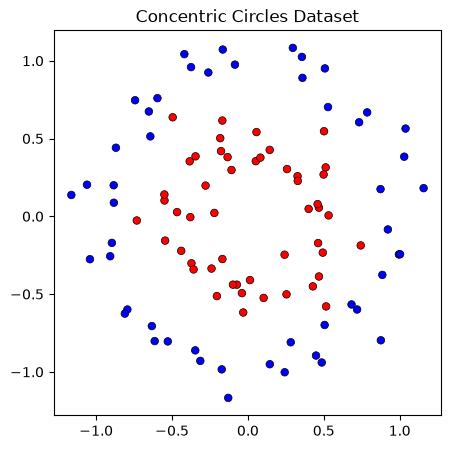

In [18]:
np.random.seed(42)   # fix all randomness so the points are identical every run
random.seed(42)

# make_circles returns two numpy arrays:
#   X : shape (100, 2) — one [horizontal, vertical] coordinate pair per point
#   y : shape (100,)   — one label per point: 0 = outer ring, 1 = inner ring
X, y = make_circles(n_samples=100, noise=0.1, factor=0.5)
# print(f'X = {X}')
print(f'y = {y}')

# Remap labels {0, 1} -> {-1, +1} for the hinge loss:
#   outer ring: 0 -> -1      inner ring: 1 -> +1
y = y * 2 - 1

# Draw it. X[:, 0] = horizontal coords, X[:, 1] = vertical coords.
# c=y colours each dot by its label (cmap 'bwr': -1 -> blue, +1 -> red).
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr', edgecolors='k', linewidth=0.5)
plt.title('Concentric Circles Dataset')
plt.show()

### The loss function

The intro's four-step loop had a "Score" step: turn "how wrong were we?" into a single number, the **loss**. Now we make that number concrete.

The network outputs one number per point. Positive means "I think this is the inner ring (+1)", negative means "I think this is the outer ring (-1)." We need a formula that is small when the prediction is right and large when it's wrong.

We use the **hinge loss**: `max(0, 1 - y * prediction)`, where `y` is the true label (+1 or -1). The best way to see why it works is to plug in a few cases. Take a point whose true label is `y = +1` (inner ring):

- Prediction = **2.5** (correct, confident): `max(0, 1 - 1*2.5)` = `max(0, -1.5)` = **0**. No loss — right answer, and sure about it.
- Prediction = **0.3** (correct, but barely): `max(0, 1 - 1*0.3)` = `max(0, 0.7)` = **0.7**. Some loss — right side of zero, but we want it to commit harder.
- Prediction = **-1.0** (wrong): `max(0, 1 - 1*(-1.0))` = `max(0, 2.0)` = **2.0**. Big loss — wrong *and* confident.

So the loss is zero once a point is on the correct side with a margin, and grows the more wrong the prediction is. The `max(0, ...)` is exactly the `relu()` we already built. We average the per-point losses into one number for the whole dataset — that single number is what we'll drive downward.

(Why hinge loss and not something you may have heard of, like cross-entropy? Hinge loss needs no probabilities and no statistics, just the raw score and a `max`. It's the simplest thing that does the job here.)

### But how does a per-point loss learn a *circle*?

Notice the formula never mentions circles, rings, or geometry. For a single point it only ever sees two numbers: that point's label `y` (`+1` or `-1`) and the network's score for it. All it asks is "does the score have the right sign, by a comfortable margin?"

So where does the circle come from? Entirely from the **labels**. The inner points are the ones tagged `+1`, the outer points are tagged `-1` — that assignment is the *only* place the ring shape lives. When we sum the loss over all 100 points and drive it down, we're making 100 demands at once: "score every inner point positive, score every outer point negative." The single arrangement that satisfies all of them together is a boundary that wraps around the inner cluster — a ring. The loss applies pressure one point at a time; the circular boundary is simply what the network is forced into to relieve that pressure everywhere simultaneously.

The very same hinge loss would train a classifier for blobs, spirals, or any other shape without changing a character — only the labels would differ.

### The training loop

Now every piece from the intro exists: a network that **predicts**, and a loss that **scores**. Here is the four-step loop, made literal — with one bookkeeping step added:

1. **Predict (forward pass)** — push every point through the network and collect its output.
2. **Score (loss)** — run those outputs through the hinge-loss formula to get one number.
3. **Assign blame (backward pass)** — call `loss.backward()`. This is the autograd from Step 2 doing its single reverse sweep, filling in `.grad` on all 337 parameters. Each `.grad` says how the loss would change if that parameter grew slightly.
4. **Nudge (the update)** — for each parameter, subtract a small fraction of its gradient: `p.data -= rate * p.grad`. The gradient points toward *higher* loss, so we step the opposite way. This is **gradient descent**, and the fraction is the **learning rate** — how big a step to take.
5. **Reset (`zero_grad`)** — clear every `.grad` before the next round, because they accumulate with `+=` (Step 2) and we don't want this step's gradients polluting the next.

Then repeat. Each pass, the loss should drop a little and the accuracy should climb.

### Reading the `train()` code

Two things trip everyone up here, so read them before the code below.

**Is training done per point?** No. Each `step` runs *every* point through the network, collects all their losses, **averages them into one number**, and takes **one** weight update from that average. So the shape of a step is "all points in → one loss → one update," repeated `steps` times. There is no per-point update. (With the default `batch_size=None`, "all points" means all 100 — this is called **full-batch** gradient descent. Step 7 swaps in a random subset per step, but it's still one update per step.)

**How the loss gets computed.** These two lines do all of it:

```python
losses = [(1 + -yi * pred).relu() for yi, pred in zip(yb, preds)]
loss   = sum(losses) * (1.0 / len(losses))
```

- The list comprehension pairs each label with its prediction (`zip(yb, preds)`) and computes **one hinge loss per point**. The expression `(1 + -yi * pred)` is just `1 - yi·pred` written awkwardly, and `.relu()` is the `max(0, …)` — so each element is `max(0, 1 - yi·pred)`, the hinge loss from above. `losses` ends up a list of 100 `Value`s.
- `sum(losses)` adds them into a single `Value` (total loss); `* (1.0 / len(losses))` divides by the count → the **mean** loss. That one `Value` is `loss`.

Because all 100 per-point losses were joined into this single `Value` through `+` and `*` (every one recorded in the computation graph from Step 2), calling `loss.backward()` **once** flows gradients from that number back through all points and into all 337 parameters. One forward pass over the batch, one backward pass, one update.

**What each variable is:**

| Variable | What it holds |
|---|---|
| `model`, `X`, `y` | the network, all input coordinates, all labels |
| `steps`, `lr` | number of iterations; learning rate (update step size) |
| `lr_decay`, `l2_alpha`, `batch_size` | optional features from Step 7; defaults leave them off |
| `step` | current iteration number |
| `Xb`, `yb` | the batch this step (`b` = "batch"); equal to `X`, `y` when `batch_size=None` |
| `preds` | list of network outputs, one `Value` per point |
| `losses` | list of per-point hinge losses (`Value`s) |
| `loss` | the single averaged loss — the number we minimize |
| `acc` | accuracy, a plain float, **printed and plotted only** (the network is not trained on it) |
| `history` | list of `(step, loss, accuracy)` per step, returned so `plot_history` can draw the run |
| `rate`, `p` | the learning rate used this step; one parameter during the update |

Note `acc` is built from `.data` (raw numbers, outside the graph) and never enters the loss. The network is trained on the smooth `loss`; accuracy is just the human-readable scoreboard.

Step   0  loss=1.1909  accuracy=51%
Step  10  loss=0.8099  accuracy=52%
Step  20  loss=0.4487  accuracy=79%
Step  30  loss=0.1265  accuracy=98%
Step  40  loss=0.0697  accuracy=99%
Step  50  loss=0.0513  accuracy=99%
Step  60  loss=0.0397  accuracy=99%
Step  70  loss=0.0374  accuracy=99%
Step  80  loss=0.0364  accuracy=99%
Step  90  loss=0.0360  accuracy=99%
Step  99  loss=0.0272  accuracy=100%


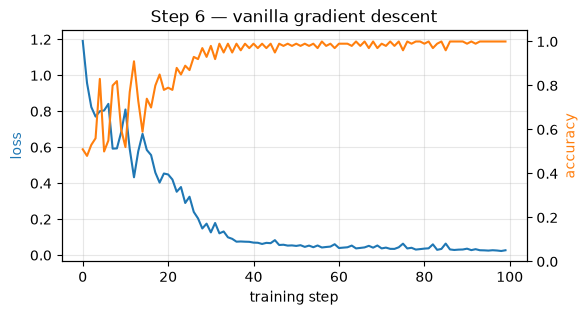

In [14]:
def train(model, X, y, steps=100, lr=0.5, lr_decay=False, l2_alpha=0, batch_size=None):
    history = []   # (step, loss, accuracy) per step, so we can plot the run afterwards
    for step in range(steps):
        # Pick this step's batch: all 100 points by default (full-batch),
        # or a random subset when batch_size is set (Step 7's mini-batches).
        if batch_size:
            idx = np.random.permutation(len(X))[:batch_size]
            Xb, yb = X[idx], y[idx]
        else:
            Xb, yb = X, y

        # 1. Predict (forward pass): every point through the network -> one Value each
        preds = [model([Value(float(x[0])), Value(float(x[1]))]) for x in Xb]

        # 2. Score: hinge loss max(0, 1 - y*pred) per point, then average into ONE Value
        losses = [(1 + -yi * pred).relu() for yi, pred in zip(yb, preds)]
        loss = sum(losses) * (1.0 / len(losses))
        if l2_alpha:
            # L2 penalty (Step 7): discourage huge weights by adding their squares to the loss
            loss = loss + l2_alpha * sum(p * p for p in model.parameters())

        # Accuracy, from raw .data (outside the graph): fraction of points whose score
        # has the correct sign. Printed and plotted only — the network trains on `loss`.
        acc = sum((yi > 0) == (p.data > 0) for yi, p in zip(yb, preds)) / len(yb)
        history.append((step, loss.data, acc))

        # 3. Assign blame (backward pass): zero_grad first — grads accumulate with +=
        model.zero_grad()
        loss.backward()

        # 4. Nudge: step every parameter against its gradient.
        # With lr_decay (Step 7) the rate shrinks linearly from lr down to 0.1*lr.
        rate = lr * (1 - 0.9 * step / steps) if lr_decay else lr
        for p in model.parameters():
            p.data -= rate * p.grad

        if step % 10 == 0 or step == steps - 1:
            print(f'Step {step:3d}  loss={loss.data:.4f}  accuracy={acc*100:.0f}%')
    return history


def plot_history(history, title):
    steps_, losses_, accs_ = zip(*history)
    fig, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(steps_, losses_, color='tab:blue')
    ax1.set_xlabel('training step'); ax1.set_ylabel('loss', color='tab:blue')
    ax2 = ax1.twinx()                       # second y-axis sharing the same x
    ax2.plot(steps_, accs_, color='tab:orange')
    ax2.set_ylabel('accuracy', color='tab:orange'); ax2.set_ylim(0, 1.05)
    ax1.set_title(title); ax1.grid(alpha=0.3)
    plt.show()


# Step 6: vanilla full-batch gradient descent, fixed learning rate
random.seed(42)
model = MLP(2, [16, 16, 1])
history = train(model, X, y, lr=0.5)
plot_history(history, 'Step 6 — vanilla gradient descent')


## Step 7: Optimizations

Vanilla gradient descent works, but it has some problems that show up in practice. Here are three simple improvements. Each one adds a single parameter to the `train()` call.

### Learning rate decay

The learning rate controls how big each weight update is. A fixed rate is a problem: if it's large, the model makes fast progress early on but once it gets close to a good solution, it keeps overshooting. You'll see the loss jumping around (0.05, 0.08, 0.04, 0.09) instead of settling down. If the rate is small, it converges smoothly but takes forever to get there.

Learning rate decay gives you both: start with a large rate for fast initial progress, then gradually shrink it so the model can settle into a precise minimum. In the code, the rate starts at 1.0 and decays to 0.1 over the course of training.

Step   0  loss=1.1909  accuracy=51%


Step  10  loss=0.5152  accuracy=82%


Step  20  loss=0.3947  accuracy=84%


Step  30  loss=0.1510  accuracy=94%


Step  40  loss=0.0589  accuracy=97%


...

Step  60  loss=0.0404  accuracy=99%


Step  70  loss=0.0355  accuracy=99%


Step  80  loss=0.0313  accuracy=100%


Step  90  loss=0.0284  accuracy=100%


Step  99  loss=0.0271  accuracy=100%


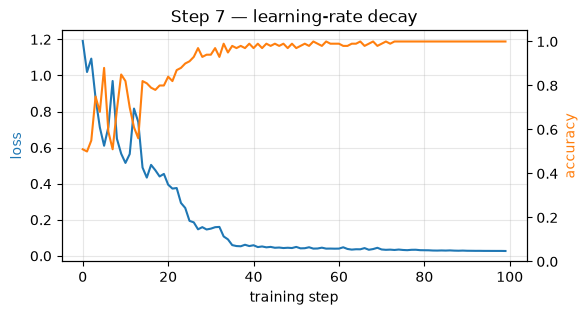

In [13]:
random.seed(42)
model = MLP(2, [16, 16, 1])
history = train(model, X, y, lr=1.0, lr_decay=True)
plot_history(history, 'Step 7 — learning-rate decay')

### L2 regularization

Without any constraints, the model is free to crank certain weights up to huge values to perfectly nail every single training point, including the noise. This is **overfitting**: it aces the training set but falls apart on new data, because it memorized the noise instead of learning the real pattern.

L2 regularization is a simple fix: add a penalty to the loss that's proportional to the sum of squared weights. A weight of 10.0 contributes 100 to the penalty, while a weight of 1.0 contributes just 1. This pushes the model toward smaller, more balanced weights. Smaller weights produce smoother decision boundaries, which tend to generalize better to data the model hasn't seen before.

The `l2_alpha` parameter controls the trade-off: too high and you constrain the model so much it can't learn the pattern, too low and it has no effect. A value like `1e-4` is a common starting point.

Step   0  loss=1.2015  accuracy=51%


Step  10  loss=0.5387  accuracy=80%


Step  20  loss=0.3875  accuracy=84%


Step  30  loss=0.2056  accuracy=92%


Step  40  loss=0.0612  accuracy=98%


...

Step  60  loss=0.0514  accuracy=100%


Step  70  loss=0.0563  accuracy=98%


Step  80  loss=0.0482  accuracy=100%


Step  90  loss=0.0439  accuracy=100%


Step  99  loss=0.0425  accuracy=100%


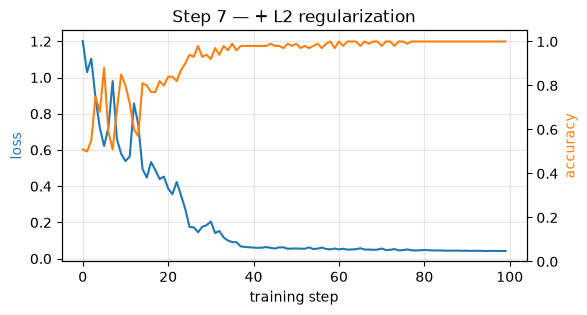

In [14]:
random.seed(42)
model = MLP(2, [16, 16, 1])
history = train(model, X, y, lr=1.0, lr_decay=True, l2_alpha=1e-4)
plot_history(history, 'Step 7 — + L2 regularization')

### Mini-batch training

So far, every training step feeds *all* 100 samples through the network, computes the loss over all of them, then updates the weights once. That's fine with 100 data points, but real datasets have millions. You'd wait ages for a single weight update.

Mini-batch training grabs a random subset (say, 20 samples) each step. The gradient you compute is noisier, since it's based on a sample rather than the full dataset, but each step is much faster. Over many steps, the model sees all the data, just in different random combinations each time. Because each step now uses a *random* batch, this is what puts the "stochastic" in **stochastic gradient descent (SGD)** — the name you'll see for this everywhere.

Surprisingly, the noise often *helps*. A gradient computed from 20 random samples points in roughly the right direction but not exactly. This randomness makes it harder for the model to memorize specific data points, which acts like a built-in regularizer. Mini-batches of 16 to 64 are the standard in practice, even when you *could* afford full-batch training.

Notice in the output below that the accuracy jumps around more than in the full-batch runs. That's the noise from sampling. The trend is still downward, it's just bumpier.

Step   0  loss=1.3653  accuracy=50%


Step  10  loss=0.4387  accuracy=90%


Step  20  loss=0.8916  accuracy=70%


Step  30  loss=0.5158  accuracy=70%


Step  40  loss=0.2038  accuracy=100%


...

Step  60  loss=0.2200  accuracy=85%


Step  70  loss=0.1067  accuracy=95%


Step  80  loss=0.0487  accuracy=100%


Step  90  loss=0.0437  accuracy=100%


Step  99  loss=0.0376  accuracy=100%


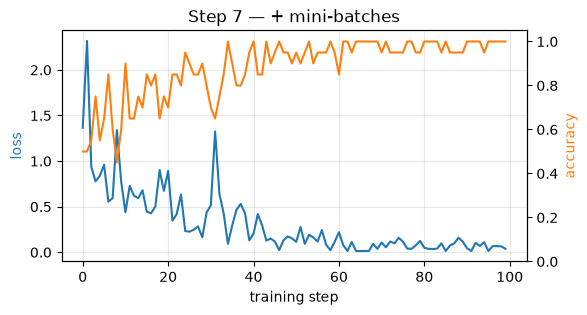

In [15]:
random.seed(42)
np.random.seed(42)
model = MLP(2, [16, 16, 1])
history = train(model, X, y, lr=1.0, lr_decay=True, l2_alpha=1e-4, batch_size=20)
plot_history(history, 'Step 7 — + mini-batches')

## Step 8: Visualizing the decision boundary

Training gave us falling loss and rising accuracy, but those are just numbers. What rule did the network actually learn? We can *see* it, because the input is 2-D: we can color every point of the plane by what the network would predict there.

### How the picture is made

The network only answers for one point at a time, so we sample the whole plane on a grid and ask the network about each grid point:

1. **Lay down a grid.** Cover the region around the data with a fine rectangular grid of points, spaced `h = 0.1` apart. (`np.meshgrid` builds the grid; `np.c_` reshapes it into a long list of `[x, y]` points.)
2. **Score every grid point.** Run each one through the trained `model`, exactly as we did for real data, getting a raw score.
3. **Threshold at zero.** `score > 0` → inner (class +1), else outer (class −1) — the same sign test from Step 6, now applied across the whole plane. This assigns a class to every grid cell (the array `Z`).
4. **Fill and overlay.** `contourf` paints each region by its class (red = inner, blue = outer); `scatter` then drops the real data points on top, colored by their *true* label, so you can check they land in the matching region.

The line where the color flips from red to blue is the **decision boundary**: the set of points where the score is exactly 0. It's the actual frontier the network uses to tell the rings apart. If training worked, it wraps the inner cluster and the dots sit cleanly inside their own colors.

### Why the boundary is made of straight lines

Look closely: the boundary isn't a smooth circle — it's a **polygon**, a ring of straight segments with sharp corners. That's not a rendering artifact (a finer grid would sharpen those edges, not round them). It's a fundamental property of a ReLU network: **the whole network is a piecewise-linear function of its input, so it can only ever produce straight-edged boundaries.** The chain of reasons:

- A single neuron's pre-activation, `w·x + b`, is a **linear** function of the input. The set of points where it equals any fixed value is a straight line (a flat hyperplane in higher dimensions). No curve anywhere.
- **ReLU** adds no curvature either: it's flat on the left, flat on the right, with a single crease at zero. It bends a linear function *once*, into two flat pieces.
- Adding and composing such functions — which is all the layers do — keeps everything **piecewise-linear**. The combined effect: the ReLU creases from all the neurons chop the plane into many polygonal regions, and *inside each region the network's score is a single flat, tilted plane*.
- The decision boundary is where that score crosses 0. Because the score is linear within each region, "score = 0" is a straight segment there. Stitch those segments across neighboring regions and you get the polygonal ring you see.

So the network approximates the circle the way a many-sided polygon approximates a circle: out of lots of small straight pieces. Each hidden neuron contributes roughly one more crease, so **more hidden neurons → more segments → a closer (but still straight-edged) fit.** The only way to get genuinely curved boundaries is to swap ReLU for a smooth activation like `tanh` or sigmoid — those bend, and the boundary bends with them.

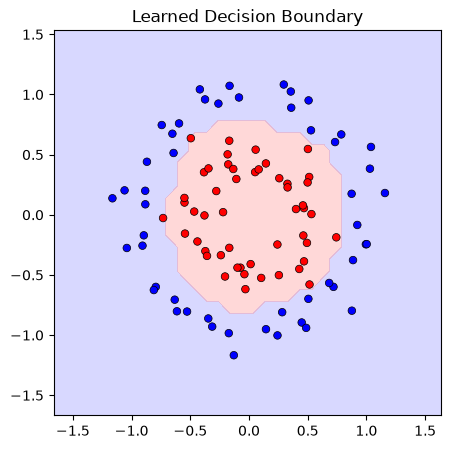

In [16]:
# The input is 2-D, so we can SEE the learned rule by coloring the whole plane.
# The model scores one point at a time, so we sample the plane on a grid and score each cell.

h = 0.1   # grid spacing (smaller = finer, crisper render — but the boundary stays polygonal)

# Plot bounds: the data's extent, padded by 0.5 on every side so we see some margin around it.
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# meshgrid makes two matrices holding the x- and y-coordinate of every grid cell.
# ravel() flattens each to 1-D, and np.c_ pairs them into a long list of [x, y] grid points.
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_grid = np.c_[xx.ravel(), yy.ravel()]

# Run EVERY grid point through the trained network -> one raw score per point.
scores = [model([Value(float(pt[0])), Value(float(pt[1]))]) for pt in X_grid]

# Threshold at 0 (the same sign test): score > 0 -> inner (+1), else outer (-1).
# reshape folds the flat list of classes back into the grid's 2-D shape so it can be drawn.
Z = np.array([s.data > 0 for s in scores]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)   # fill each region by predicted class (red=inner, blue=outer)
# Overlay the real data points, colored by their TRUE label, to check they land in the right region.
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr', edgecolors='k', linewidth=0.5)
plt.title('Learned Decision Boundary')
plt.show()

## Summary

What we built, and how it connects:

| Component | What it does |
|-----------|-------------|
| `Value` | Wraps a number, records every operation, computes all derivatives in one backward pass |
| `Neuron` | Weighted sum of inputs + bias + ReLU |
| `Layer` / `MLP` | Groups neurons into layers, chains layers into a network |
| `train()` | The learning loop: predict, score, assign blame, nudge, repeat |

The whole thing traces back to the four-step loop in the intro. Training a neural network is just computing derivatives (how does each knob affect the loss?) and then turning the knobs to reduce that loss. The `Value` class automates the derivative computation (Steps 1–3), the network classes organize the knobs (Steps 4–5), and the training loop does the turning (Steps 6–7).

This is how PyTorch works under the hood: same autograd, same backpropagation. The difference is scale. PyTorch operates on tensors (big arrays of numbers) on GPUs instead of individual scalars. The [embeddings notebook](embeddings.ipynb) picks up right here: it swaps our scalar `Value` for PyTorch tensors (and verifies they are the same autograd engine on the exact ring example from this notebook), then builds our first language model — an MLP that predicts the next character of Shakespeare, with every parameter still created and updated by hand.

### What we learned

- **Training is one loop**: predict, score, assign blame, nudge. Everything else in deep learning is this loop with a bigger model in the middle.
- **The derivative is the nudge signal** — its sign says which way to move a parameter, its magnitude says how much that parameter matters right now.
- **Backpropagation computes every parameter's derivative in one backward pass**, by recording the computation graph and replaying it in reverse with the chain rule. Gradients accumulate with `+=` because a value used in two places collects blame from both paths.
- **An autograd engine is small**: ~60 lines of Python. PyTorch's `loss.backward()` is this exact machine, scaled to tensors.
- **Without a nonlinearity, depth is fake** — stacked linear layers collapse into one. ReLU (or any bend) is what lets a network learn curved shapes.
- **A neuron has exactly one weight per input, plus one bias.** Parameter counts are just this rule, added up (337 here).
- **The loss never sees geometry.** The ring shape lives entirely in the labels; the loss only pressures each point's score, and the boundary emerges from satisfying all points at once.
- **A ReLU network is piecewise linear** — its decision boundary is always straight segments, which is why more neurons make a rounder-looking polygon, never a true curve.

### A note on dying ReLU

There's a subtle problem with ReLU: if a neuron's weights land in a state where the weighted sum is negative for *every* input in the dataset, its gradient is always zero (the closed gate from Step 3), so the weights never get updated. The neuron is permanently dead. This can happen from unlucky random initialization, or from a learning rate that's too large (a big update overshoots and pushes the weights into a region where the neuron never fires again).

Common fixes in practice:

- **Leaky ReLU**: instead of `max(0, x)`, use `max(0.01x, x)`. Negative inputs get a small slope instead of flat zero, so the gradient is 0.01 instead of 0. Tiny, but enough for the weights to keep moving.
- **Better initialization**: schemes like He initialization scale the random weights based on the number of inputs, reducing the chance of neurons starting dead.
- **Lower learning rates**: smaller updates are less likely to catapult weights into a permanently negative region.

Our notebook uses plain ReLU because it's the simplest to understand and works fine for a small network with 100 data points. In larger networks, dying neurons become a real concern.


## Your turn: make it stick

Reading along is the comfortable half of learning. Before moving on, do these two things — they take an hour and are worth more than a second read-through.

### 1. Summarize it yourself, then verify with an LLM

Close the notebook and write a summary from memory — a few sentences per question, no peeking:

- What are the four steps of the training loop, and what does each one produce?
- What is a derivative *for*, in training terms? Why compute it for every parameter?
- How does backpropagation get every derivative in one pass? Why do gradients accumulate with `+=`?
- Why does a network need ReLU (or any nonlinearity) at all?
- Where does the ring shape "live" — in the loss formula, the network, or the labels? Why is the learned boundary made of straight segments?

Then paste your summary into an LLM (Claude, ChatGPT) with a prompt like:

> *"I just studied backpropagation and neural network training by building an autograd engine from scratch. Here is my summary from memory: [your summary]. Check every claim for correctness, tell me what I've missed or muddled, then quiz me with three follow-up questions aimed at my weakest spot."*

Argue back where you disagree — that argument is where the learning happens.

### 2. Rebuild a small version

From a blank file, no copying (referring back when stuck is fine — but type, don't paste):

1. Write a `Value` class supporting only `+`, `*`, and `relu()`, with `backward()`.
2. **Verify it**: run `d = (a + b) * b` with `a=2, b=3` and check you get `a.grad = 3, b.grad = 8`. Then check a `relu` case against the numerical nudge method from Step 1 — `(f(x+h) - f(x)) / h` should match your `.grad` to ~3 decimals.
3. Build a tiny MLP (2 inputs → 4 hidden → 1 output) on top of it and train it on XOR: inputs `[0,0],[0,1],[1,0],[1,1]`, targets `-1,+1,+1,-1`. XOR is the smallest task that *forces* the hidden layer to matter — a single neuron provably can't do it.

**Done when**: the numerical check matches, and all four XOR points classify correctly. If XOR won't converge, try more hidden neurons or a smaller learning rate — and notice that debugging this *is* the lesson.

> ➡ **Next in the series:** [Language Modeling with Embeddings — an MLP](embeddings.ipynb)
